In [1]:
# git clone https://github.com/xinntao/BasicSR.git BasicSR
# cd BasicSR && pip install -e . && cd ..

# git clone https://github.com/megvii-research/NAFNet.git NAFNet_Folder
# cd NAFNet_Folder && pip install -e . 
# cd ..

# git clone https://github.com/xinntao/Real-ESRGAN.git Realesrgan_Folder
# cd Realesrgan_Folder && pip install -e . && cd ..

# git clone https://github.com/xinntao/BasicSR.git BasicVSR_Folder
# cd BasicVSR_Folder && pip install -e . && cd ..

In [ ]:
import sys, os, importlib.util
from contextlib import contextmanager
import cv2
import time
import numpy as np
import torch
import gdown
import tempfile
import os
from PIL import Image
import matplotlib.pyplot as plt
# from basicsr.archs.basicvsr_plusplus_arch import BasicVSRPlusPlus
# from basicsr.archs.nafnet_arch import NAFNet
# from basicsr.archs.rrdbnet_arch import RRDBNet
# from realesrgan import RealESRGANer RealESRGANModel
from torch.hub import load_state_dict_from_url
from torchvision.transforms import ToTensor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
def import_from_repo(repo_root, module_path, function_names, prepend=True):
    # в repo_root теперь может быть либо строка, либо список строк
    roots = repo_root if isinstance(repo_root, (list, tuple)) else [repo_root]

    @contextmanager
    def adjusted_repo_context():
        orig_sys = sys.path.copy()
        orig_cwd = os.getcwd()
        if prepend:
            # вставляем все корни сверху
            for r in roots:
                sys.path.insert(0, r)
        else:
            for r in roots:
                sys.path.append(r)
        os.chdir(roots[-1])
        try:
            yield
        finally:
            sys.path = orig_sys
            os.chdir(orig_cwd)
            # очищаем модули, начинающиеся с нужного топ-level
            top = module_path.split('.')[0]
            for mod in list(sys.modules):
                if mod.startswith(top):
                    del sys.modules[mod]

    with adjusted_repo_context():
        # сброс регистра архитектур в basicsr (если есть)
        try:
            from basicsr.utils.registry import ARCH_REGISTRY
            ARCH_REGISTRY._obj_map.clear()
        except (ImportError, AttributeError):
            pass

        spec = importlib.util.spec_from_file_location(
            module_path,
            os.path.join(roots[-1], *module_path.split('.')) + ".py"
        )
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        return {name: getattr(module, name) for name in function_names}

In [3]:
# NAFNet
repo1_funcs = import_from_repo(
    repo_root="/home/student/ma/NAFNet_Folder",
    module_path="basicsr.models.archs.NAFNet_arch",
    function_names=["NAFNet"]
)

# BasicVSR++
repo2_funcs = import_from_repo(
    repo_root="/home/student/ma/BasicVSR_Folder",
    module_path="basicsr.archs.basicvsr_arch",
    function_names=["BasicVSR"]
)

# RRDBNet
repo3_funcs = import_from_repo(
    repo_root="/home/student/ma/BasicVSR_Folder",
    module_path="basicsr.archs.rrdbnet_arch",
    function_names=["RRDBNet"]
)

# RealESRGAN
repo4_funcs = import_from_repo(
    repo_root=["/home/student/ma/BasicSR", "/home/student/ma/Realesrgan_Folder"],
    module_path="realesrgan.utils",
    function_names=["RealESRGANer"]
)

In [4]:
# Теперь используем функции с префиксами
NAFNet = repo1_funcs["NAFNet"] # Функция из первого репозитория
BasicVSR = repo2_funcs["BasicVSR"]  # Функция из второго репозитория
RRDBNet = repo3_funcs["RRDBNet"] # Функция из второго репозитория
RealESRGANer = repo4_funcs["RealESRGANer"]

In [ ]:
# Депиксилизация с Real-ESRGAN (гитхаб kokutoru слишком специфичен, я честно не смог адаптировать)
def depixelate_frame(frame):
    model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)

    state_dict = load_state_dict_from_url('https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth')
    with tempfile.NamedTemporaryFile(delete=False) as f:
        torch.save(state_dict, f)
        model_path = f.name
    try:
        upsampler = RealESRGANer(
            scale=4,
            model_path=model_path,
            model=model,
            tile=0,
            tile_pad=10,
            pre_pad=0,
            half=False,
            device=device
        )

        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        output, _ = upsampler.enhance(img, outscale=4)

        result = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)
    finally:
        os.unlink(model_path)

    return result

# Улучшение кадра с NAFNet
def enhance_frame_nafnet(frame):
    model = NAFNet(
        img_channel=3,
        width=64,
        middle_blk_num=1,
        enc_blk_nums=[1, 1, 1, 28],
        dec_blk_nums=[1, 1, 1, 1]
    )

    # url = "https://drive.google.com/uc?id=1S0PVRbyTakYY9a82kujgZLbMihfNBLfC"
    # output = "NAFNet_weights.pth"
    # gdown.download(url, output, quiet=True)
    # checkpoint = torch.load(output)
    # model.load_state_dict(checkpoint["params"])

    checkpoint = torch.load("/home/student/ma/NAFNet_weights.pth", map_location=device)
    model.load_state_dict(checkpoint["params"])
    model = model.to(device).eval()

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_tensor = ToTensor()(Image.fromarray(img)).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)

    result = output.squeeze().permute(1,2,0).cpu().numpy()
    return cv2.cvtColor((result * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

# Медианное усреднение кадров
def median_weightening(frames):
    return np.median(np.stack(frames), axis=0).astype(np.uint8)

# Динамическое взвешенное усреднение кадров
def dynamic_weightening(frames):
    weights = []
    for frame in frames:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
        sharpness = np.sqrt(gx**2 + gy**2).mean()
        weights.append(sharpness)

    weights = np.array(weights)
    if weights.sum() == 0:
        weights = np.ones_like(weights)
    weights /= weights.sum()

    avg_frame = np.zeros_like(frames[0], dtype=np.float32)
    for i, frame in enumerate(frames):
        avg_frame += frame.astype(np.float32) * weights[i]

    return avg_frame.astype(np.uint8)

# Увелечение разрешения с BasicVSR
def super_resolution(frame):         # по идеи должно было быть SR++ , но автор веса не скинул, есть альтернатива mmagic, но там с импортами беда
    model = BasicVSR(num_feat=64, num_block=30) # веса тут - https://drive.google.com/drive/u/0/folders/1FM36uk2OT01_ZgsF1LUfN4GPzRaS0N1l?sort=13&direction=a
    checkpoint = torch.load("/home/student/ma/BasicVSR_REDS4-543c8261.pth", map_location=device)
    model.load_state_dict(checkpoint["params"])
    model = model.to(device).eval()

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_tensor = ToTensor()(Image.fromarray(img)).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0))

    result = output.squeeze().permute(1,2,0).cpu().numpy()
    return cv2.cvtColor((result * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

In [6]:
def extract_frames(video_path, target_fps=24):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps

    frames = []
    for sec in range(int(duration)):
        frame_indices = [int(sec * fps + (i * fps / target_fps)) for i in range(target_fps)]
        for fi in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
    cap.release()
    return frames[:24]

def process_frames(frames, use_median=True, crop_region=None):
    processed = []
    for frame in frames:
        if crop_region:
            x1, y1, x2, y2 = crop_region
            frame = frame[y1:y2, x1:x2]

        depixelated = depixelate_frame(frame)
        enhanced = enhance_frame_nafnet(depixelated)
        processed.append(enhanced)

    if use_median:
        averaged = median_weightening(processed)
    else:
        averaged = dynamic_weightening(processed)

    final = super_resolution(averaged)
    return final

def process_video(video_path, crop_region):
    frames = extract_frames(video_path)

    orig_frames = process_frames(frames, crop_region=None)
    cropped_frames = process_frames(frames, crop_region=crop_region)

    return orig_frames, cropped_frames

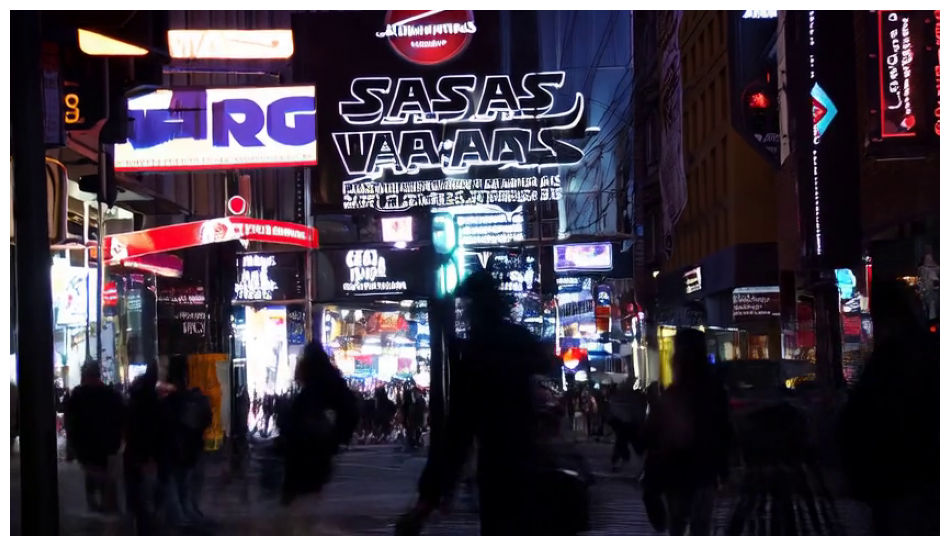

In [ ]:
cap = cv2.VideoCapture("/home/student/ma/video.mp4")
if not cap.isOpened():
    raise Exception("Could not open video file")

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fig = plt.figure(figsize=(12, 8))
target_frame = int(fps * 1)
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
ret, frame = cap.read()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    display(fig)
else:
    raise Exception("Failed to read frame")

cap.release()
plt.close()

In [ ]:
video_path = "/home/student/ma/video.mp4"
crop_region = (100, 100, 400, 400)          # Пример области обрезки (x1,y1,x2,y2)
image, cropped_image = process_video(video_path, crop_region)

/home/student/ma/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/student/ma/.venv/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


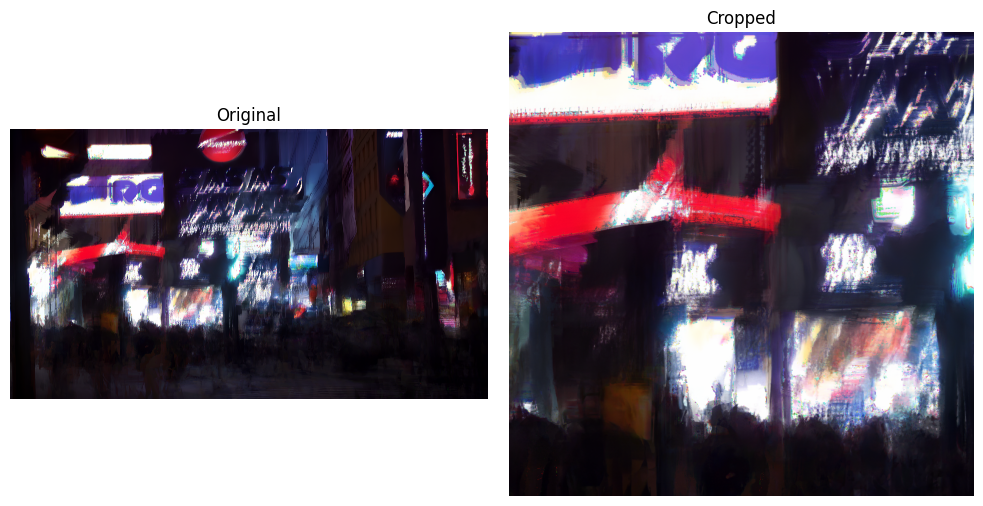

In [13]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(cropped_image)
axes[1].set_title("Cropped")
axes[1].axis('off')

plt.tight_layout()
plt.show()